# Module 3: Bias Correction and Domain Downscaling

This module connects model development with domain-wide inference.

## Learning objectives

By the end of the module, participants will be able to:

1. Explain why bias correction is evaluated against a raw GEOS baseline.
2. Progress from linear regression to Random Forest and a DNN.
3. Apply a fixed global min–max table consistently during training and inference.
4. Distinguish statistical bias correction from spatial downscaling.
5. Run the production v3.1 correction and downscaling models for one historical timestamp.
6. Compare GEOS, corrected, downscaled, and downscaled-corrected PM2.5 with ground observations.

The notebook has two sections:

- **Section 1:** progressive station-level bias-correction models
- **Section 2:** domain-wide v3.1 inference, downscaling, and four-panel evaluation


## 0. Colab setup and reproducibility

The setup cell retrieves the participant repository and installs the declared
dependencies. A GPU speeds up DNN training but is not required for the compact
demonstration.


In [ ]:
# --- What this cell does ---
# Clones the participant repository in a fresh Colab runtime.
# Locates the same project root when the notebook runs from a local clone.
# Installs the shared scientific Python environment used by this module.
# --- End annotation ---
from pathlib import Path
import subprocess
import sys

REPO_NAME = "GEOS_Air_Quality_Training_Bangkok_2026"
REPO_URL = "https://github.com/alqamahsayeed12/GEOS_Air_Quality_Training_Bangkok_2026.git"
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    TRAINING_ROOT = Path("/content") / REPO_NAME
    if not (TRAINING_ROOT / ".git").exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", REPO_URL, str(TRAINING_ROOT)],
            check=True,
        )
    else:
        subprocess.run(
            ["git", "-C", str(TRAINING_ROOT), "pull", "--ff-only"],
            check=True,
        )
else:
    candidates = [Path.cwd(), Path.cwd().parent]
    TRAINING_ROOT = next(
        (path.resolve() for path in candidates if (path / "requirements-colab.txt").exists()),
        None,
    )
    if TRAINING_ROOT is None:
        raise FileNotFoundError("Run this notebook from the cloned repository.")

requirements_path = TRAINING_ROOT / "requirements-colab.txt"
print("Python:", sys.version.split()[0])
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "-r", str(requirements_path)],
    check=True,
)
print("Training root:", TRAINING_ROOT)

from pathlib import Path
import os
import random
import sys
import warnings

import keras
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import tensorflow as tf
import xarray as xr

import cartopy.crs as ccrs
import cartopy.feature as cfeature

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

MODULE3_DATA = TRAINING_ROOT / "data" / "module3"
MODEL_ASSETS = MODULE3_DATA / "model_assets"
OUTPUT_DIR = TRAINING_ROOT / "outputs" / "module3"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRAINING_SAMPLE = (
    MODULE3_DATA / "aqms_geos_collocated_training_sample_day1.csv"
)
STATIC_SCALAR_FILE = MODEL_ASSETS / "max_min4.csv"
DOMAIN_SAMPLE = MODULE3_DATA / "module3_geos_domain_20230509_1930.nc"
GROUND_SAMPLE = MODULE3_DATA / "module3_ground_20230509_1930.csv"

for required_path in [
    TRAINING_SAMPLE,
    STATIC_SCALAR_FILE,
    DOMAIN_SAMPLE,
    GROUND_SAMPLE,
]:
    if not required_path.exists():
        raise FileNotFoundError(required_path)

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
print("Training root:", TRAINING_ROOT)
print("Output directory:", OUTPUT_DIR)


# Section 1: Progressive bias correction

We begin with a transparent baseline and add model complexity gradually:

1. **Raw GEOS:** no correction; every new method must be compared with it.
2. **Linear regression:** learns a straight-line correction from GEOS PM2.5.
3. **Random Forest:** learns nonlinear relationships and interactions.
4. **DNN:** learns nonlinear combinations from the same normalized feature matrix.

This progression separates the benefit of additional complexity from the benefit of simply fitting any correction.


## 1.1 Load and screen the collocated training sample

The target is the three-hour ground observation. Predictors include meteorology, aerosol species, AOD, and three GEOS PM2.5 baselines. We retain only complete three-hour ground averages (`obs_n_obs = 3`) and PM2.5 values from 1 through 1,000 µg/m³.


In [2]:
# --- What this cell does ---
# Loads the station-level Day 1 sample produced by the earlier collocation workflow.
# Applies the agreed QA/QC rules and locks the production feature order.
# --- End annotation ---

# Keep feature order fixed because normalization arrays and trained models use this exact order.
FEATURE_COLUMNS = [
    "WIND", "PS", "Q500", "Q850", "QV10M", "T10M", "T500", "T850",
    "U10M", "V10M", "BCSMASS", "DUSMASS25", "OCSMASS", "SO2SMASS",
    "SO4SMASS", "SSSMASS25", "TOTEXTTAU",
]
BASELINE_COLUMNS = ["PM25", "BC_MLPM25", "GEOSPM25"]
MODEL_FEATURE_COLUMNS = FEATURE_COLUMNS + BASELINE_COLUMNS
TARGET_COLUMN = "observed_pm25"

model_data = pd.read_csv(
    TRAINING_SAMPLE,
    parse_dates=["initialization_time", "datetime_utc", "datetime_local"],
)
for column in MODEL_FEATURE_COLUMNS + [TARGET_COLUMN, "obs_n_obs"]:
    model_data[column] = pd.to_numeric(model_data[column], errors="coerce")

# QA/QC is repeated after loading so the model never relies on undocumented prior filtering.
# Apply QA/QC before splitting so every model sees the same eligible records.
valid_rows = (
    model_data["obs_n_obs"].eq(3)
    & model_data[TARGET_COLUMN].between(1, 1000, inclusive="both")
    & model_data["GEOSPM25"].between(1, 1000, inclusive="both")
)
model_data = (
    model_data.loc[valid_rows]
    .dropna(subset=MODEL_FEATURE_COLUMNS + [TARGET_COLUMN])
    .reset_index(drop=True)
)

print("Analysis rows:", f"{len(model_data):,}")
print("Stations:", model_data["station_code"].nunique())
print("Valid-time range:", model_data["datetime_utc"].min(), "to", model_data["datetime_utc"].max())
display(
    model_data[[
        "station_code", "initialization_time", "datetime_utc",
        "GEOSPM25", TARGET_COLUMN, "obs_n_obs",
    ]].head()
)


Analysis rows: 4,997
Stations: 11
Valid-time range: 2020-02-05 19:30:00 to 2024-09-30 07:30:00


,station_code,initialization_time,datetime_utc,GEOSPM25,observed_pm25,obs_n_obs
0,AQMS06,2020-02-05,2020-02-05 19:30:00,39.909962,49.300000,3
1,AQMS06,2020-02-05,2020-02-05 22:30:00,42.923901,41.033333,3
2,AQMS06,2020-02-06,2020-02-06 22:30:00,58.155704,73.600000,3
3,AQMS09,2020-02-08,2020-02-08 04:30:00,22.077053,31.000000,3
4,AQMS06,2020-02-08,2020-02-08 07:30:00,24.094269,25.633333,3


## 1.2 Why use a fixed global min–max table?

Min–max normalization converts each predictor to a comparable numerical scale:

\[
x_{scaled} = 
rac{x-x_{min}}{x_{max}-x_{min}}
\]

The critical choice is where `x_min` and `x_max` come from. We use a **static global table**, not minima and maxima fitted to today's batch or this teaching sample.

This matters because:

- training and inference receive the same numerical meaning;
- predictions do not change merely because the operational domain or date changed;
- the scalar table becomes a versioned model asset;
- values outside `[0, 1]` provide a useful warning that new data exceed the training envelope.

Linear regression and Random Forest do not strictly require scaling, but using one documented feature matrix makes the comparison and handoff to the DNN explicit.


In [3]:
# --- What this cell does ---
# Loads global minima and maxima from the static scalar asset.
# Adds the documented 0-1,000 µg/m³ range for PM2.5 baseline predictors.
# Applies the same transformation to every row without fitting new scalars.
# --- End annotation ---

# Load global training-era scalars rather than estimating new limits from this sample.
static_scalars = pd.read_csv(STATIC_SCALAR_FILE, index_col=0)
static_min = static_scalars["mn"].astype(float).copy()
static_max = static_scalars["mx"].astype(float).copy()

# PM2.5 baseline ranges are fixed by the analysis validity contract.
for baseline_column in BASELINE_COLUMNS:
    static_min.loc[baseline_column] = 0.0
    static_max.loc[baseline_column] = 1000.0

static_min = static_min.reindex(MODEL_FEATURE_COLUMNS)
static_max = static_max.reindex(MODEL_FEATURE_COLUMNS)
if static_min.isna().any() or static_max.isna().any():
    missing = static_min.index[static_min.isna() | static_max.isna()].tolist()
    raise ValueError(f"Missing static scalars for: {missing}")


def global_minmax_normalize(frame, minimum, maximum):
    '''Apply saved global scalars; do not fit, clip, or silently replace values.'''
    # Use one denominator per feature and stop if any declared range is zero or missing.
    denominator = maximum - minimum
    if (denominator <= 0).any():
        raise ValueError("Every global maximum must exceed its minimum.")
    return (frame - minimum) / denominator


# Apply the production min-max equation column by column in the locked feature order.
normalized_features = global_minmax_normalize(
    model_data[MODEL_FEATURE_COLUMNS],
    static_min,
    static_max,
).astype("float32")

normalization_audit = pd.DataFrame({
    "global_min": static_min,
    "global_max": static_max,
    "sample_min_scaled": normalized_features.min(),
    "sample_max_scaled": normalized_features.max(),
    "below_zero": (normalized_features < 0).sum(),
    "above_one": (normalized_features > 1).sum(),
})

print("The scaler was loaded from disk; no sample-specific fit was performed.")
display(normalization_audit)


The scaler was loaded from disk; no sample-specific fit was performed.


,global_min,global_max,sample_min_scaled,sample_max_scaled,below_zero,above_one
WIND,0.0,15.000,0.002901,0.643230,0,0
PS,30000.0,104000.000,0.815081,0.960277,0,0
Q500,0.0,0.008,0.000111,0.908087,0,0
Q850,0.0,0.020,0.074393,0.888586,0,0
QV10M,0.0,0.030,0.145770,0.738541,0,0
T10M,200.0,320.000,0.668110,0.948705,0,0
T500,200.0,280.000,0.732099,0.941007,0,0
T850,200.0,302.000,0.708207,0.996474,0,0
U10M,-100.0,100.000,0.451914,0.525929,0,0
V10M,-100.0,100.000,0.473755,0.526213,0,0


## 1.3 Create one reproducible train/test split

All three correction algorithms use the same held-out rows. This makes their metrics directly comparable. The split seed is fixed and printed; operational studies should also consider time-blocked or station-held-out evaluation.


In [4]:
# --- What this cell does ---
# Creates one fixed row-wise train/test division shared by all demonstration models.
# Keeps row indices so predictions can be joined back to station and timestamp metadata.
# --- End annotation ---

all_indices = np.arange(len(model_data))
# Fix the random seed so every teaching model is evaluated on the same held-out rows.
train_indices, test_indices = train_test_split(
    all_indices,
    test_size=0.20,
    random_state=RANDOM_SEED,
    shuffle=True,
)

X_train_scaled = normalized_features.iloc[train_indices]
X_test_scaled = normalized_features.iloc[test_indices]
y_train = model_data.loc[train_indices, TARGET_COLUMN].to_numpy(dtype="float32")
y_test = model_data.loc[test_indices, TARGET_COLUMN].to_numpy(dtype="float32")

X_train_linear = model_data.loc[train_indices, ["GEOSPM25"]]
X_test_linear = model_data.loc[test_indices, ["GEOSPM25"]]

print("Split seed:", RANDOM_SEED)
print("Training rows:", f"{len(train_indices):,}")
print("Test rows:", f"{len(test_indices):,}")


Split seed: 42
Training rows: 3,997
Test rows: 1,000


## 1.4 Train the linear and Random Forest corrections

The linear model answers a simple question: can one slope and intercept improve GEOS? The Random Forest uses all predictors and can learn nonlinear thresholds and interactions. The forest is intentionally modest so it trains quickly during the workshop.


In [5]:
# --- What this cell does ---
# Trains a one-predictor linear correction and a multivariable Random Forest.
# Generates held-out predictions without exposing test targets during fitting.
# --- End annotation ---

linear_model = LinearRegression()
# Fit only on training targets; the test targets remain unseen until evaluation.
linear_model.fit(X_train_linear, y_train)
linear_prediction = linear_model.predict(X_test_linear)

# The tree ensemble provides a nonlinear benchmark between linear correction and the DNN.
rf_model = RandomForestRegressor(
    n_estimators=180,
    max_depth=16,
    min_samples_leaf=3,
    max_features="sqrt",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
rf_model.fit(X_train_scaled, y_train)
rf_prediction = rf_model.predict(X_test_scaled)

print(
    "Linear equation: observed PM2.5 = "
    f"{linear_model.intercept_:.3f} + "
    f"{linear_model.coef_[0]:.3f} × GEOSPM25"
)
print("Random Forest trees:", len(rf_model.estimators_))


Linear equation: observed PM2.5 = 46.714 + 0.251 × GEOSPM25
Random Forest trees: 180


## 1.5 Train a demonstration DNN in Colab

This compact DNN uses the same 20 globally normalized predictors as the Random Forest. Early stopping restores the epoch with the lowest validation loss. It is a teaching model, not a replacement for the production v3.1 fold-and-ensemble system used in Section 2.


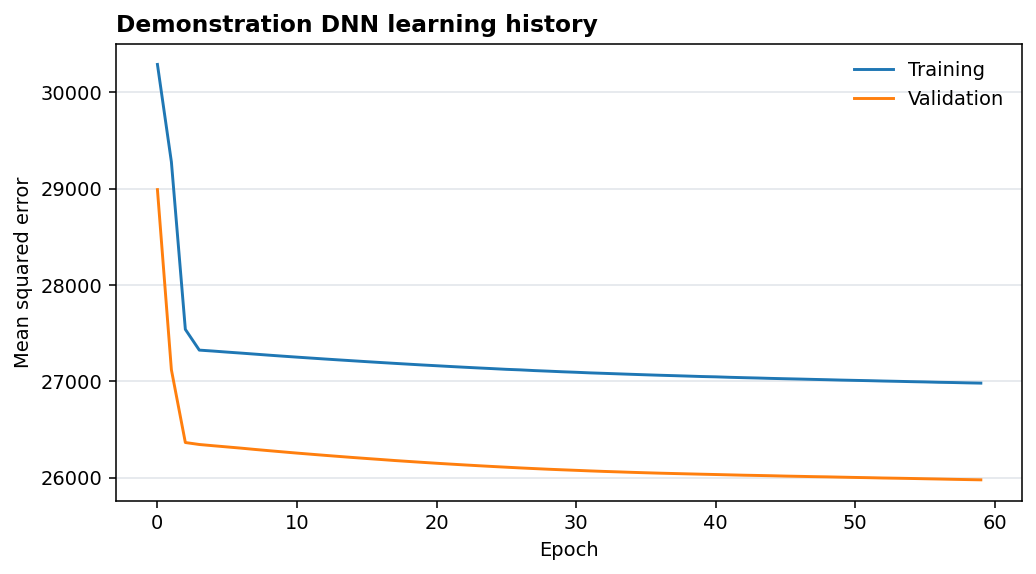

Epochs completed: 60
Saved: {TRAINING_ROOT}/outputs/module3/module3_demo_dnn.keras
Saved: {TRAINING_ROOT}/outputs/module3/module3_demo_dnn_learning_history.png


In [6]:
# --- What this cell does ---
# Defines and trains a compact dense neural network for PM2.5 regression.
# Uses validation-based early stopping to reduce overfitting.
# Saves the trained teaching model so inference can be reproduced.
# --- End annotation ---

keras.backend.clear_session()
tf.random.set_seed(RANDOM_SEED)

# Build a compact multilayer perceptron for tabular station-time predictors.
dnn_model = keras.Sequential([
    keras.Input(shape=(len(MODEL_FEATURE_COLUMNS),), name="normalized_predictors"),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dense(1, activation="relu", name="pm25_prediction"),
], name="module3_demo_dnn")
dnn_model.compile(
    # Use a fixed learning rate so the demonstration is reproducible across runtimes.
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=[keras.metrics.RootMeanSquaredError(name="rmse")],
)

# Stop when validation loss no longer improves and restore the best epoch's weights.
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    min_delta=1e-3,
    restore_best_weights=True,
)
history = dnn_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.20,
    epochs=60,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=0,
)
dnn_prediction = dnn_model.predict(X_test_scaled, batch_size=512, verbose=0).reshape(-1)

demo_dnn_path = OUTPUT_DIR / "module3_demo_dnn.keras"
dnn_model.save(demo_dnn_path)

fig, ax = plt.subplots(figsize=(7.5, 4.2), dpi=140)
ax.plot(history.history["loss"], label="Training")
ax.plot(history.history["val_loss"], label="Validation")
ax.set_xlabel("Epoch")
ax.set_ylabel("Mean squared error")
ax.set_title("Demonstration DNN learning history", loc="left", fontweight="semibold")
ax.grid(axis="y", color="#e1e5ea")
ax.legend(frameon=False)
fig.tight_layout()
learning_figure = OUTPUT_DIR / "module3_demo_dnn_learning_history.png"
fig.savefig(learning_figure, dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

print("Epochs completed:", len(history.history["loss"]))
print("Saved:", demo_dnn_path)
print("Saved:", learning_figure)


## 1.6 Compare every method on the same test set

Metrics use `prediction - observation` for mean bias. IOA is the original Willmott formulation with squared error (`j = 2`). Scatter panels use the same axes and 1:1 line so apparent performance is not changed by panel scaling.


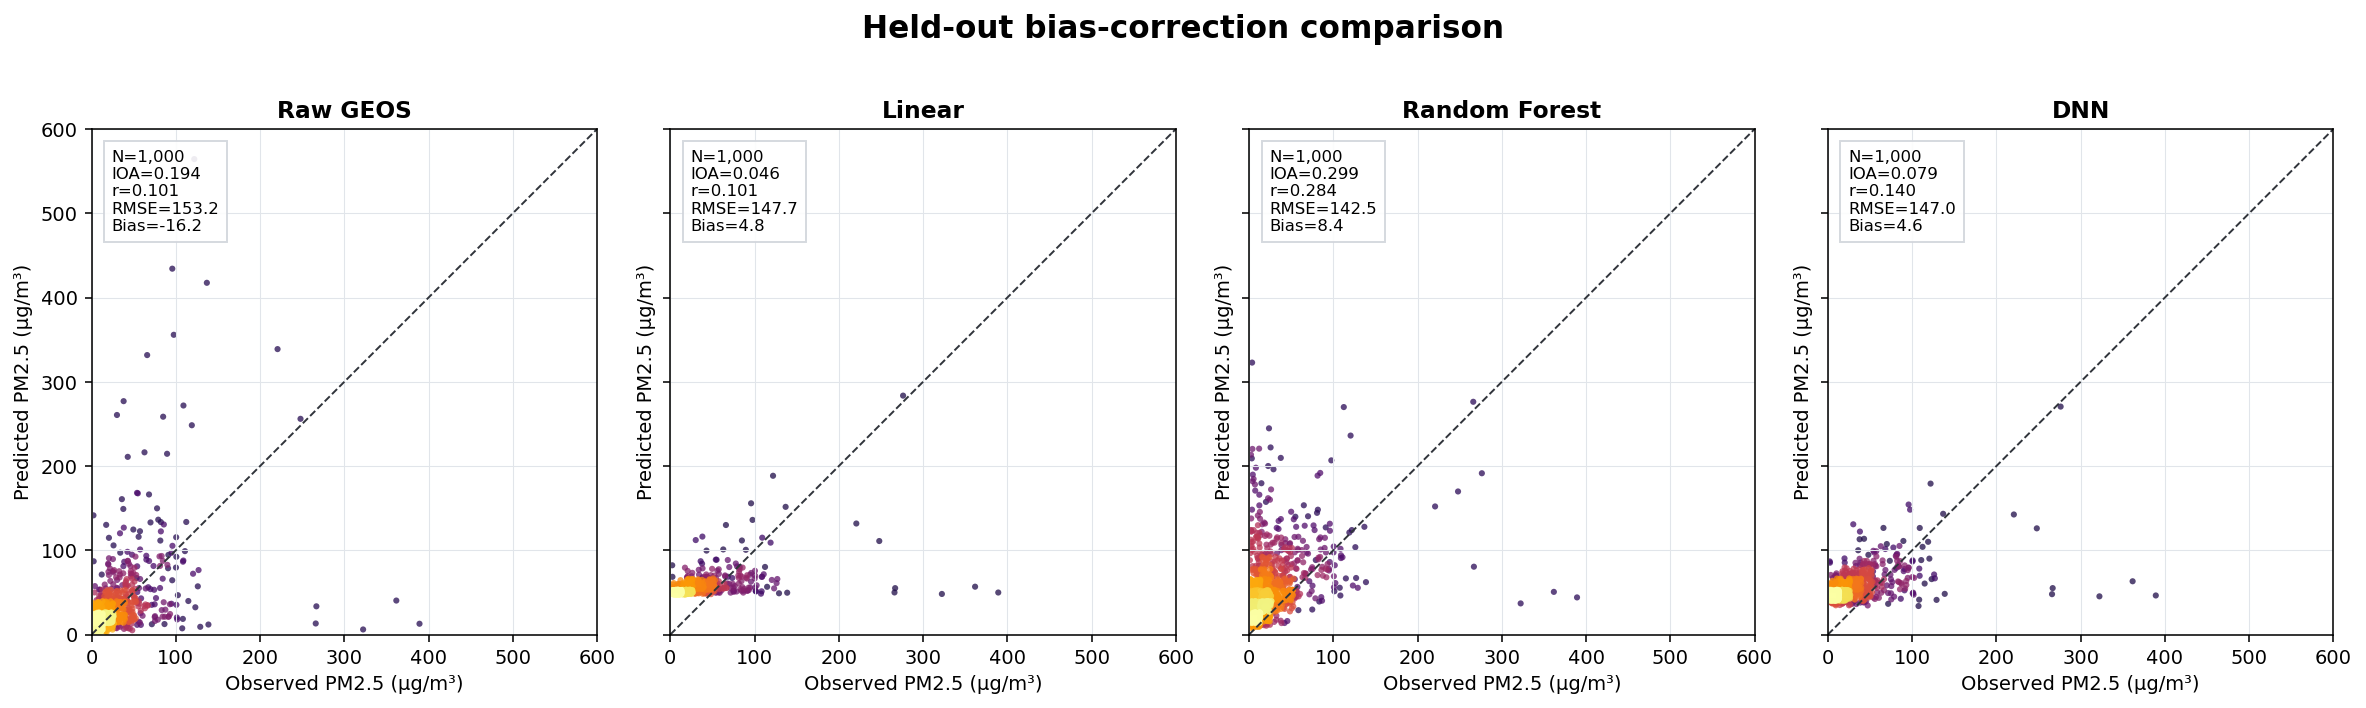

Saved: {TRAINING_ROOT}/outputs/module3/module3_bias_correction_model_metrics.csv
Saved: {TRAINING_ROOT}/outputs/module3/module3_bias_correction_model_scatter.png


,method,N,mean_bias,rmse,r,ioa
0,Raw GEOS,1000,-16.215,153.220,0.101,0.194
1,Linear,1000,4.785,147.722,0.101,0.046
2,Random Forest,1000,8.420,142.513,0.284,0.299
3,DNN,1000,4.589,147.046,0.140,0.079


In [7]:
# --- What this cell does ---
# Calculates identical held-out metrics for raw GEOS, linear, RF, and DNN predictions.
# Produces a four-panel density-colored scatter comparison with common axes.
# --- End annotation ---

def evaluation_metrics(observed, predicted):
    observed = np.asarray(observed, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    # Evaluate every product using the same finite observed-predicted pairs.
    finite = np.isfinite(observed) & np.isfinite(predicted)
    observed = observed[finite]
    predicted = predicted[finite]
    error = predicted - observed
    observed_mean = observed.mean()
    denominator = np.sum(
        (np.abs(predicted - observed_mean) + np.abs(observed - observed_mean)) ** 2
    )
    correlation = (
        np.corrcoef(observed, predicted)[0, 1]
        if observed.std() > 0 and predicted.std() > 0
        else np.nan
    )
    return {
        "N": len(observed),
        "mean_bias": error.mean(),
        "rmse": np.sqrt(np.mean(error ** 2)),
        "r": correlation,
        "ioa": 1 - np.sum(error ** 2) / denominator if denominator > 0 else np.nan,
    }


prediction_sets = {
    "Raw GEOS": model_data.loc[test_indices, "GEOSPM25"].to_numpy(),
    "Linear": linear_prediction,
    "Random Forest": rf_prediction,
    "DNN": dnn_prediction,
}

metric_rows = []
for method, prediction in prediction_sets.items():
    metric_rows.append({"method": method, **evaluation_metrics(y_test, prediction)})
model_comparison = pd.DataFrame(metric_rows)
comparison_output = OUTPUT_DIR / "module3_bias_correction_model_metrics.csv"
model_comparison.to_csv(comparison_output, index=False)

all_plot_values = np.concatenate(
    [y_test] + [np.asarray(values) for values in prediction_sets.values()]
)
axis_max = float(
    np.clip(np.ceil(np.nanpercentile(all_plot_values, 99.5) / 50) * 50, 100, 1000)
)

fig, axes = plt.subplots(1, 4, figsize=(17, 4.8), dpi=140, sharex=True, sharey=True)
for ax, (method, prediction) in zip(axes, prediction_sets.items()):
    metric = model_comparison.loc[model_comparison["method"].eq(method)].iloc[0]
    observed = np.asarray(y_test)
    predicted = np.asarray(prediction)
    histogram, x_edges, y_edges = np.histogram2d(
        observed,
        predicted,
        bins=45,
        range=[[0, axis_max], [0, axis_max]],
    )
    x_index = np.clip(np.digitize(observed, x_edges) - 1, 0, histogram.shape[0] - 1)
    y_index = np.clip(np.digitize(predicted, y_edges) - 1, 0, histogram.shape[1] - 1)
    density = histogram[x_index, y_index]
    order = np.argsort(density)
    ax.scatter(
        observed[order],
        predicted[order],
        c=np.log1p(density[order]),
        cmap="inferno",
        s=10,
        alpha=0.75,
        edgecolors="none",
    )
    ax.plot([0, axis_max], [0, axis_max], "--", color="#30343b", linewidth=1)
    ax.set_xlim(0, axis_max)
    ax.set_ylim(0, axis_max)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(method, fontweight="semibold")
    ax.set_xlabel("Observed PM2.5 (µg/m³)")
    ax.set_ylabel("Predicted PM2.5 (µg/m³)")
    ax.grid(color="#e1e5ea", linewidth=0.55)
    ax.text(
        0.04,
        0.96,
        f"N={int(metric['N']):,}\nIOA={metric['ioa']:.3f}\n"
        f"r={metric['r']:.3f}\nRMSE={metric['rmse']:.1f}\n"
        f"Bias={metric['mean_bias']:.1f}",
        transform=ax.transAxes,
        va="top",
        fontsize=8.5,
        bbox={"facecolor": "white", "edgecolor": "#d1d5db", "alpha": 0.90},
    )

fig.suptitle("Held-out bias-correction comparison", fontsize=16, fontweight="semibold")
fig.tight_layout(rect=[0, 0, 1, 0.94])
comparison_figure = OUTPUT_DIR / "module3_bias_correction_model_scatter.png"
fig.savefig(comparison_figure, dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved:", comparison_output)
print("Saved:", comparison_figure)
display(model_comparison.round(3))


# Section 2: Production v3.1 correction and spatial downscaling

The production chain contains two distinct operations:

1. **v3.1 bias correction at the native GEOS grid:** ten fold DNNs generate intermediate predictions, then an ensemble DNN produces corrected PM2.5.
2. **Spatial downscaling:** the convolutional model converts each native PM2.5 field to the approximately 5 km grid.

For one timestamp, we therefore produce four fields:

| Panel | Field | Meaning |
|---|---|---|
| 1 | GEOS PM2.5 | Native uncorrected GEOS field |
| 2 | Bias-corrected GEOS PM2.5 | Native GEOS field after statistical correction |
| 3 | Downscaled GEOS PM2.5 | Spatially downscaled uncorrected field |
| 4 | Bias-corrected and downscaled GEOS PM2.5 | Statistical correction plus spatial downscaling |

This historical timestamp has two complete Lao PDR AQMS observations. They are overlaid for workflow demonstration; two stations are not enough for a robust domain-wide score.


## 2.1 Load the historical domain and matching ground observations

The model domain is larger than Lao PDR because the convolutional downscaling model needs spatial context and dimensions compatible with its architecture. The final map is cropped to Lao PDR and neighboring areas.


In [8]:
# --- What this cell does ---
# Opens a one-timestamp historical GEOS feature cube with a model-compatible 120×160 grid.
# Loads ground PM2.5 observations at the same UTC valid time.
# --- End annotation ---

# Load the compact feature cube into memory so subsequent inference is deterministic and offline.
domain_source = xr.open_dataset(DOMAIN_SAMPLE).load()
ground_at_valid_time = pd.read_csv(
    GROUND_SAMPLE,
    parse_dates=["valid_time_utc"],
)

valid_time = pd.Timestamp(domain_source["time"].values[0], tz="UTC")
print("Initialization time (UTC):", domain_source.attrs["initialization_time_utc"])
print("Valid time (UTC):", valid_time)
print("Forecast day:", domain_source.attrs["forecast_day"])
print("Native model grid:", domain_source.sizes)
print("Ground observations:", len(ground_at_valid_time))
display(ground_at_valid_time)


Initialization time (UTC): 2023-05-09 00:00:00+00:00
Valid time (UTC): 2023-05-09 19:30:00+00:00
Forecast day: 1
Native model grid: Frozen({'lat': 120, 'lon': 160, 'time': 1})
Ground observations: 2


,network,station_code,station_name,lat,lon,valid_time_utc,ground_pm25_3h,n_obs
0,Lao PDR AQMS,AQMS02,Thakhek,17.40475,104.808250,2023-05-09 19:30:00+00:00,14.333333,3.0
1,Lao PDR AQMS,AQMS05,Luang Namtha,20.93075,101.415778,2023-05-09 19:30:00+00:00,14.566667,3.0


## 2.2 Apply the production v3.1 fold and ensemble models

The feature order and static scaling must match training exactly. Each fold receives 20 normalized predictors. The ensemble then receives those 20 predictors plus the ten fold predictions. Fold predictions use a fixed 0–1,000 µg/m³ scale in the ensemble input.


In [9]:
# --- What this cell does ---
# Loads the ten Day 1 v3.1 fold models and their ensemble model without training them again.
# Applies the same static normalization used during model development.
# Reconstructs native GEOS and v3.1-corrected fields on the latitude-longitude grid.
# --- End annotation ---

DNN_COLUMNS = [f"DNN_{fold:02d}" for fold in range(10)]
ENSEMBLE_FEATURE_COLUMNS = MODEL_FEATURE_COLUMNS + DNN_COLUMNS

# At terrain above the 850 hPa surface, pressure-level humidity and temperature are undefined.
# Use the corresponding near-surface variable only at those missing cells.
model_domain = domain_source.copy()
fallback_pairs = {"Q850": "QV10M", "T850": "T10M"}
for target_variable, fallback_variable in fallback_pairs.items():
    missing_before = int(model_domain[target_variable].isnull().sum())
    model_domain[target_variable] = model_domain[target_variable].where(
        model_domain[target_variable].notnull(),
        model_domain[fallback_variable],
    )
    print(
        f"{target_variable}: replaced {missing_before:,} missing values "
        f"with {fallback_variable}"
    )

# The live production stream does not supply separate PM25 and BC_MLPM25 baselines.
# Where the historical file also lacks them, use GEOSPM25 exactly as deployment does.
for baseline_variable in ["PM25", "BC_MLPM25"]:
    missing_before = int(model_domain[baseline_variable].isnull().sum())
    model_domain[baseline_variable] = model_domain[baseline_variable].where(
        model_domain[baseline_variable].notnull(),
        model_domain["GEOSPM25"],
    )
    print(
        f"{baseline_variable}: replaced {missing_before:,} missing values "
        "with GEOSPM25"
    )

# Flatten the grid into rows while preserving coordinates and the trained feature-column order.
domain_frame = model_domain[MODEL_FEATURE_COLUMNS].to_dataframe().reset_index()
domain_scaled = global_minmax_normalize(
    domain_frame[MODEL_FEATURE_COLUMNS],
    static_min,
    static_max,
).astype("float32")
if not np.isfinite(domain_scaled.to_numpy()).all():
    raise ValueError("Non-finite normalized values were found in the domain sample.")

fold_models = []
# Run all ten folds; their predictions represent model-to-model uncertainty from resampling.
for fold in range(10):
    model_path = MODEL_ASSETS / f"v3_1_dnn_bias_Correction_day1_fold{fold:02d}.h5"
    fold_model = keras.models.load_model(model_path, compile=False)
    fold_models.append(fold_model)
    domain_frame[DNN_COLUMNS[fold]] = fold_model.predict(
        domain_scaled,
        batch_size=4096,
        verbose=0,
    ).reshape(-1)

# The fold outputs are concentration predictions and use the documented PM2.5 range.
ensemble_min = static_min.copy()
ensemble_max = static_max.copy()
for dnn_column in DNN_COLUMNS:
    ensemble_min.loc[dnn_column] = 0.0
    ensemble_max.loc[dnn_column] = 1000.0
ensemble_min = ensemble_min.reindex(ENSEMBLE_FEATURE_COLUMNS)
ensemble_max = ensemble_max.reindex(ENSEMBLE_FEATURE_COLUMNS)

ensemble_scaled = global_minmax_normalize(
    domain_frame[ENSEMBLE_FEATURE_COLUMNS],
    ensemble_min,
    ensemble_max,
).astype("float32")
ensemble_model = keras.models.load_model(
    MODEL_ASSETS / "v3_1_dnn_bias_Correction_day1_ensemble.h5",
    compile=False,
)
# Combine baseline predictors and fold outputs using the trained ensemble model.
domain_frame["BC_DNN_PM25"] = ensemble_model.predict(
    ensemble_scaled,
    batch_size=4096,
    verbose=0,
).reshape(-1)

native_fields = xr.Dataset.from_dataframe(
    domain_frame[["lat", "lon", "time", "GEOSPM25", "BC_DNN_PM25"]]
    .set_index(["lat", "lon", "time"])
).astype("float32")
native_output = OUTPUT_DIR / "module3_native_v3_1_20230509_1930.nc"
native_fields.to_netcdf(native_output)

print("Fold models loaded:", len(fold_models))
print("Ensemble input features:", len(ENSEMBLE_FEATURE_COLUMNS))
print("Saved:", native_output)


Q850: replaced 3,187 missing values with QV10M
T850: replaced 3,187 missing values with T10M
PM25: replaced 3,187 missing values with GEOSPM25
BC_MLPM25: replaced 3,187 missing values with GEOSPM25


{HOME}/anaconda3/envs/goes-pm25-dnn/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
{HOME}/anaconda3/envs/goes-pm25-dnn/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


{HOME}/anaconda3/envs/goes-pm25-dnn/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
{HOME}/anaconda3/envs/goes-pm25-dnn/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


{HOME}/anaconda3/envs/goes-pm25-dnn/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
{HOME}/anaconda3/envs/goes-pm25-dnn/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


{HOME}/anaconda3/envs/goes-pm25-dnn/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
{HOME}/anaconda3/envs/goes-pm25-dnn/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


{HOME}/anaconda3/envs/goes-pm25-dnn/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
{HOME}/anaconda3/envs/goes-pm25-dnn/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold models loaded: 10
Ensemble input features: 30
Saved: {TRAINING_ROOT}/outputs/module3/module3_native_v3_1_20230509_1930.nc


{HOME}/anaconda3/envs/goes-pm25-dnn/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 2.3 Apply the convolutional downscaling model

The downscaling model operates on a spatial image, not independent table rows. Time is moved to the batch dimension, and a single PM2.5 channel is supplied. The same network is applied separately to uncorrected and v3.1-corrected fields.


In [10]:
# --- What this cell does ---
# Defines the serializable depth-to-space layer used by the Colab-compatible model asset.
# Downscales native GEOS and v3.1-corrected PM2.5 to the approximately 5 km grid.
# Preserves the same UTC valid time and writes the two downscaled fields to NetCDF.
# --- End annotation ---

@keras.saving.register_keras_serializable(package="ADPC")
class DepthToSpace(keras.layers.Layer):
    def __init__(self, block_size=5, **kwargs):
        super().__init__(**kwargs)
        self.block_size = int(block_size)

    def call(self, inputs):
        # Rearrange learned channels into a grid that is five times finer in each spatial direction.
        return tf.nn.depth_to_space(inputs, block_size=self.block_size)

    def get_config(self):
        config = super().get_config()
        config["block_size"] = self.block_size
        return config


downscale_model = keras.models.load_model(
    MODEL_ASSETS / "model_downscale_v1_colab.keras",
    custom_objects={"DepthToSpace": DepthToSpace},
    compile=False,
)


def downscale_field(data_array):
    '''Move time to the batch axis, add a channel, predict, and remove the channel.'''
    model_input = data_array.transpose("time", "lat", "lon").values[..., np.newaxis]
    return downscale_model.predict(model_input, batch_size=1, verbose=0)[..., 0]


downscaled_geos = downscale_field(native_fields["GEOSPM25"])
downscaled_corrected = downscale_field(native_fields["BC_DNN_PM25"])

# Construct explicit fine-grid coordinates so downscaled arrays retain geolocation.
new_lat = np.arange(
    float(native_fields.lat.min()) - 0.1,
    float(native_fields.lat.max()) + 0.15,
    0.05,
    dtype="float32",
)
new_lon = np.arange(
    float(native_fields.lon.min()) - 0.125,
    float(native_fields.lon.max()) + 0.1875,
    0.0625,
    dtype="float32",
)
if downscaled_geos.shape[1:] != (len(new_lat), len(new_lon)):
    raise ValueError(
        f"Model output {downscaled_geos.shape[1:]} does not match coordinates "
        f"{(len(new_lat), len(new_lon))}."
    )

downscaled_fields = xr.Dataset(
    data_vars={
        "DS_GEOSPM25": (
            ["lat", "lon", "time"],
            np.moveaxis(downscaled_geos, 0, -1).astype("float32"),
        ),
        "DS_BC_DNN_PM25": (
            ["lat", "lon", "time"],
            np.moveaxis(downscaled_corrected, 0, -1).astype("float32"),
        ),
    },
    coords={"lat": new_lat, "lon": new_lon, "time": native_fields.time},
    attrs={
        "description": "Module 3 downscaled historical PM2.5 demonstration",
        "bias_model": "v3.1: AQMS and neighboring PCD stations",
        "downscale_model": "model_downscale_v1_colab.keras",
    },
)
downscaled_output = OUTPUT_DIR / "module3_downscaled_v3_1_20230509_1930.nc"
downscaled_fields.to_netcdf(downscaled_output)

print("Native grid:", native_fields.sizes)
print("Downscaled grid:", downscaled_fields.sizes)
print("Saved:", downscaled_output)


Native grid: Frozen({'lat': 120, 'lon': 160, 'time': 1})
Downscaled grid: Frozen({'lat': 600, 'lon': 800, 'time': 1})
Saved: {TRAINING_ROOT}/outputs/module3/module3_downscaled_v3_1_20230509_1930.nc


## 2.4 Sample all four fields at the ground stations

Nearest-neighbor sampling is used only to demonstrate the comparison chain at this timestamp. A full evaluation should repeat the temporal alignment and station-level aggregation over many dates, as completed in Module 1.


In [11]:
# --- What this cell does ---
# Samples native and downscaled fields at each ground-station coordinate.
# Places observations and four model products in one traceable comparison table.
# --- End annotation ---

station_comparison_rows = []
for station in ground_at_valid_time.itertuples(index=False):
    # Sample the nearest native and downscaled cells using the same station coordinates.
    native_point = native_fields.sel(lat=station.lat, lon=station.lon, method="nearest")
    downscaled_point = downscaled_fields.sel(lat=station.lat, lon=station.lon, method="nearest")
    station_comparison_rows.append({
        "station_code": station.station_code,
        "station_name": station.station_name,
        "lat": station.lat,
        "lon": station.lon,
        "valid_time_utc": station.valid_time_utc,
        "ground_pm25": station.ground_pm25_3h,
        "geos_native_pm25": float(native_point["GEOSPM25"].values.squeeze()),
        "v3_1_native_pm25": float(native_point["BC_DNN_PM25"].values.squeeze()),
        "downscaled_geos_pm25": float(downscaled_point["DS_GEOSPM25"].values.squeeze()),
        "downscaled_v3_1_pm25": float(downscaled_point["DS_BC_DNN_PM25"].values.squeeze()),
    })

station_domain_comparison = pd.DataFrame(station_comparison_rows)
station_comparison_output = OUTPUT_DIR / "module3_station_comparison_20230509_1930.csv"
station_domain_comparison.to_csv(station_comparison_output, index=False)

print("This table contains only two stations and is a workflow check, not a validation sample.")
print("Saved:", station_comparison_output)
display(station_domain_comparison.round(2))


This table contains only two stations and is a workflow check, not a validation sample.
Saved: {TRAINING_ROOT}/outputs/module3/module3_station_comparison_20230509_1930.csv


,station_code,station_name,lat,lon,valid_time_utc,ground_pm25,geos_native_pm25,v3_1_native_pm25,downscaled_geos_pm25,downscaled_v3_1_pm25
0,AQMS02,Thakhek,17.40,104.81,2023-05-09 19:30:00+00:00,14.33,54.93,12.51,62.86,13.7
1,AQMS05,Luang Namtha,20.93,101.42,2023-05-09 19:30:00+00:00,14.57,93.16,22.45,36.70,15.6


### Bias at the two ground locations

For each product, station bias is calculated as **model PM2.5 - observed PM2.5**. Positive values indicate overprediction; negative values indicate underprediction. This two-station result is a workflow demonstration rather than a model-validation statistic.


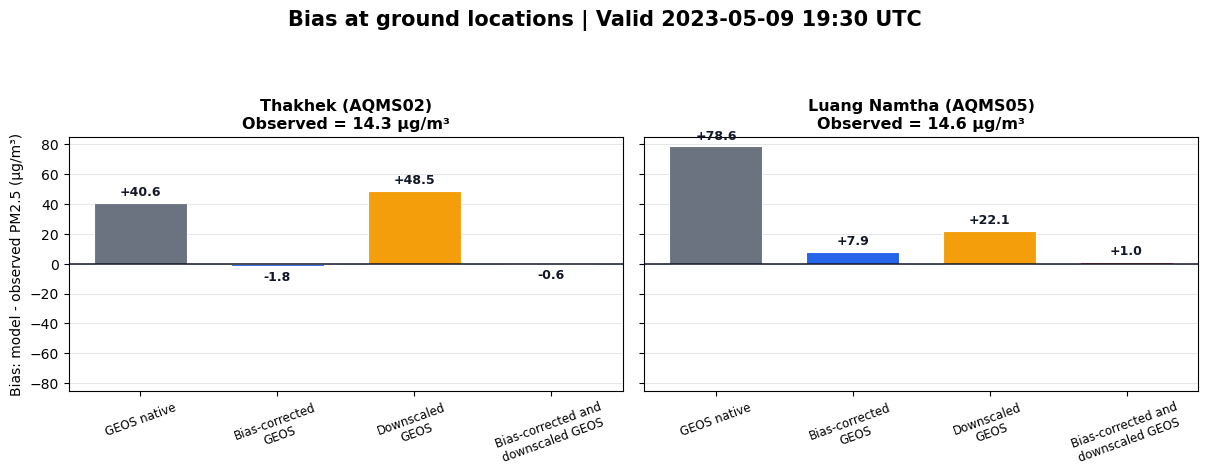

Positive bias = overprediction; negative bias = underprediction.
Saved table: {TRAINING_ROOT}/outputs/module3/module3_two_station_four_product_bias_20230509_1930.csv
Saved figure: {TRAINING_ROOT}/outputs/module3/module3_two_station_four_product_bias_20230509_1930.png


,,product,Bias-corrected GEOS,Bias-corrected and downscaled GEOS,Downscaled GEOS,GEOS native
station_code,station_name,observed_pm25,,,,
AQMS02,Thakhek,14.333333,-1.82,-0.63,48.52,40.6
AQMS05,Luang Namtha,14.566667,7.88,1.03,22.13,78.6


In [12]:
# --- What this cell does ---
# Calculates model-minus-observation bias for all four mapped PM2.5 products.
# Reshapes the two-station comparison into a traceable table.
# Draws one station panel per location using a common zero-centered bias scale.
# --- End annotation ---

product_columns = {
    "geos_native_pm25": "GEOS native",
    "v3_1_native_pm25": "Bias-corrected GEOS",
    "downscaled_geos_pm25": "Downscaled GEOS",
    "downscaled_v3_1_pm25": "Bias-corrected and downscaled GEOS",
}
product_colors = {
    "GEOS native": "#6B7280",
    "Bias-corrected GEOS": "#2563EB",
    "Downscaled GEOS": "#F59E0B",
    "Bias-corrected and downscaled GEOS": "#DC2626",
}
product_display_labels = {
    "GEOS native": "GEOS native",
    "Bias-corrected GEOS": "Bias-corrected\nGEOS",
    "Downscaled GEOS": "Downscaled\nGEOS",
    "Bias-corrected and downscaled GEOS": "Bias-corrected and\ndownscaled GEOS",
}

# Calculate signed model-minus-ground bias for direct comparison across products.
station_bias_rows = []
for station in station_domain_comparison.itertuples(index=False):
    for column, product_name in product_columns.items():
        model_value = float(getattr(station, column))
        observed_value = float(station.ground_pm25)
        station_bias_rows.append({
            "station_code": station.station_code,
            "station_name": station.station_name,
            "lat": station.lat,
            "lon": station.lon,
            "valid_time_utc": station.valid_time_utc,
            "product": product_name,
            "observed_pm25": observed_value,
            "model_pm25": model_value,
            "bias_model_minus_observed": model_value - observed_value,
        })

station_bias = pd.DataFrame(station_bias_rows)
station_bias_output = OUTPUT_DIR / "module3_two_station_four_product_bias_20230509_1930.csv"
station_bias.to_csv(station_bias_output, index=False)

max_absolute_bias = station_bias["bias_model_minus_observed"].abs().max()
bias_limit = max(5.0, np.ceil(max_absolute_bias / 5.0) * 5.0 + 5.0)

fig, axes = plt.subplots(1, len(station_domain_comparison), figsize=(12.2, 4.8), sharey=True)
axes = np.atleast_1d(axes)

for ax, station in zip(axes, station_domain_comparison.itertuples(index=False)):
    station_data = station_bias.loc[station_bias["station_code"] == station.station_code]
    bars = ax.bar(
        [product_display_labels[name] for name in station_data["product"]],
        station_data["bias_model_minus_observed"],
        color=[product_colors[name] for name in station_data["product"]],
        width=0.68,
        edgecolor="white",
        linewidth=0.8,
    )
    ax.axhline(0, color="#111827", linewidth=1.1)
    ax.set_ylim(-bias_limit, bias_limit)
    ax.grid(axis="y", color="#D1D5DB", linewidth=0.6, alpha=0.7)
    ax.set_axisbelow(True)
    ax.tick_params(axis="x", rotation=20, labelsize=8.5)
    ax.set_title(
        f"{station.station_name} ({station.station_code})\n"
        f"Observed = {station.ground_pm25:.1f} µg/m³",
        fontsize=11.5,
        fontweight="semibold",
    )

    for bar, bias_value in zip(bars, station_data["bias_model_minus_observed"]):
        vertical_offset = 3 if bias_value >= 0 else -3
        ax.annotate(
            f"{bias_value:+.1f}",
            xy=(bar.get_x() + bar.get_width() / 2, bias_value),
            xytext=(0, vertical_offset),
            textcoords="offset points",
            ha="center",
            va="bottom" if bias_value >= 0 else "top",
            fontsize=9,
            fontweight="semibold",
            color="#111827",
        )

axes[0].set_ylabel("Bias: model - observed PM2.5 (µg/m³)")
fig.suptitle(
    "Bias at ground locations | Valid 2023-05-09 19:30 UTC",
    fontsize=15,
    fontweight="semibold",
)
fig.tight_layout(rect=[0, 0, 1, 0.90])

station_bias_figure = OUTPUT_DIR / "module3_two_station_four_product_bias_20230509_1930.png"
fig.savefig(station_bias_figure, dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

print("Positive bias = overprediction; negative bias = underprediction.")
print("Saved table:", station_bias_output)
print("Saved figure:", station_bias_figure)
display(
    station_bias.pivot(
        index=["station_code", "station_name", "observed_pm25"],
        columns="product",
        values="bias_model_minus_observed",
    ).round(2)
)


## 2.5 Generate the four-panel domain plot

All panels use the same continuous AQI-inspired color scale. Ground observations are plotted as circles using that same scale, allowing direct visual comparison without implying that a station represents the entire surrounding grid cell.


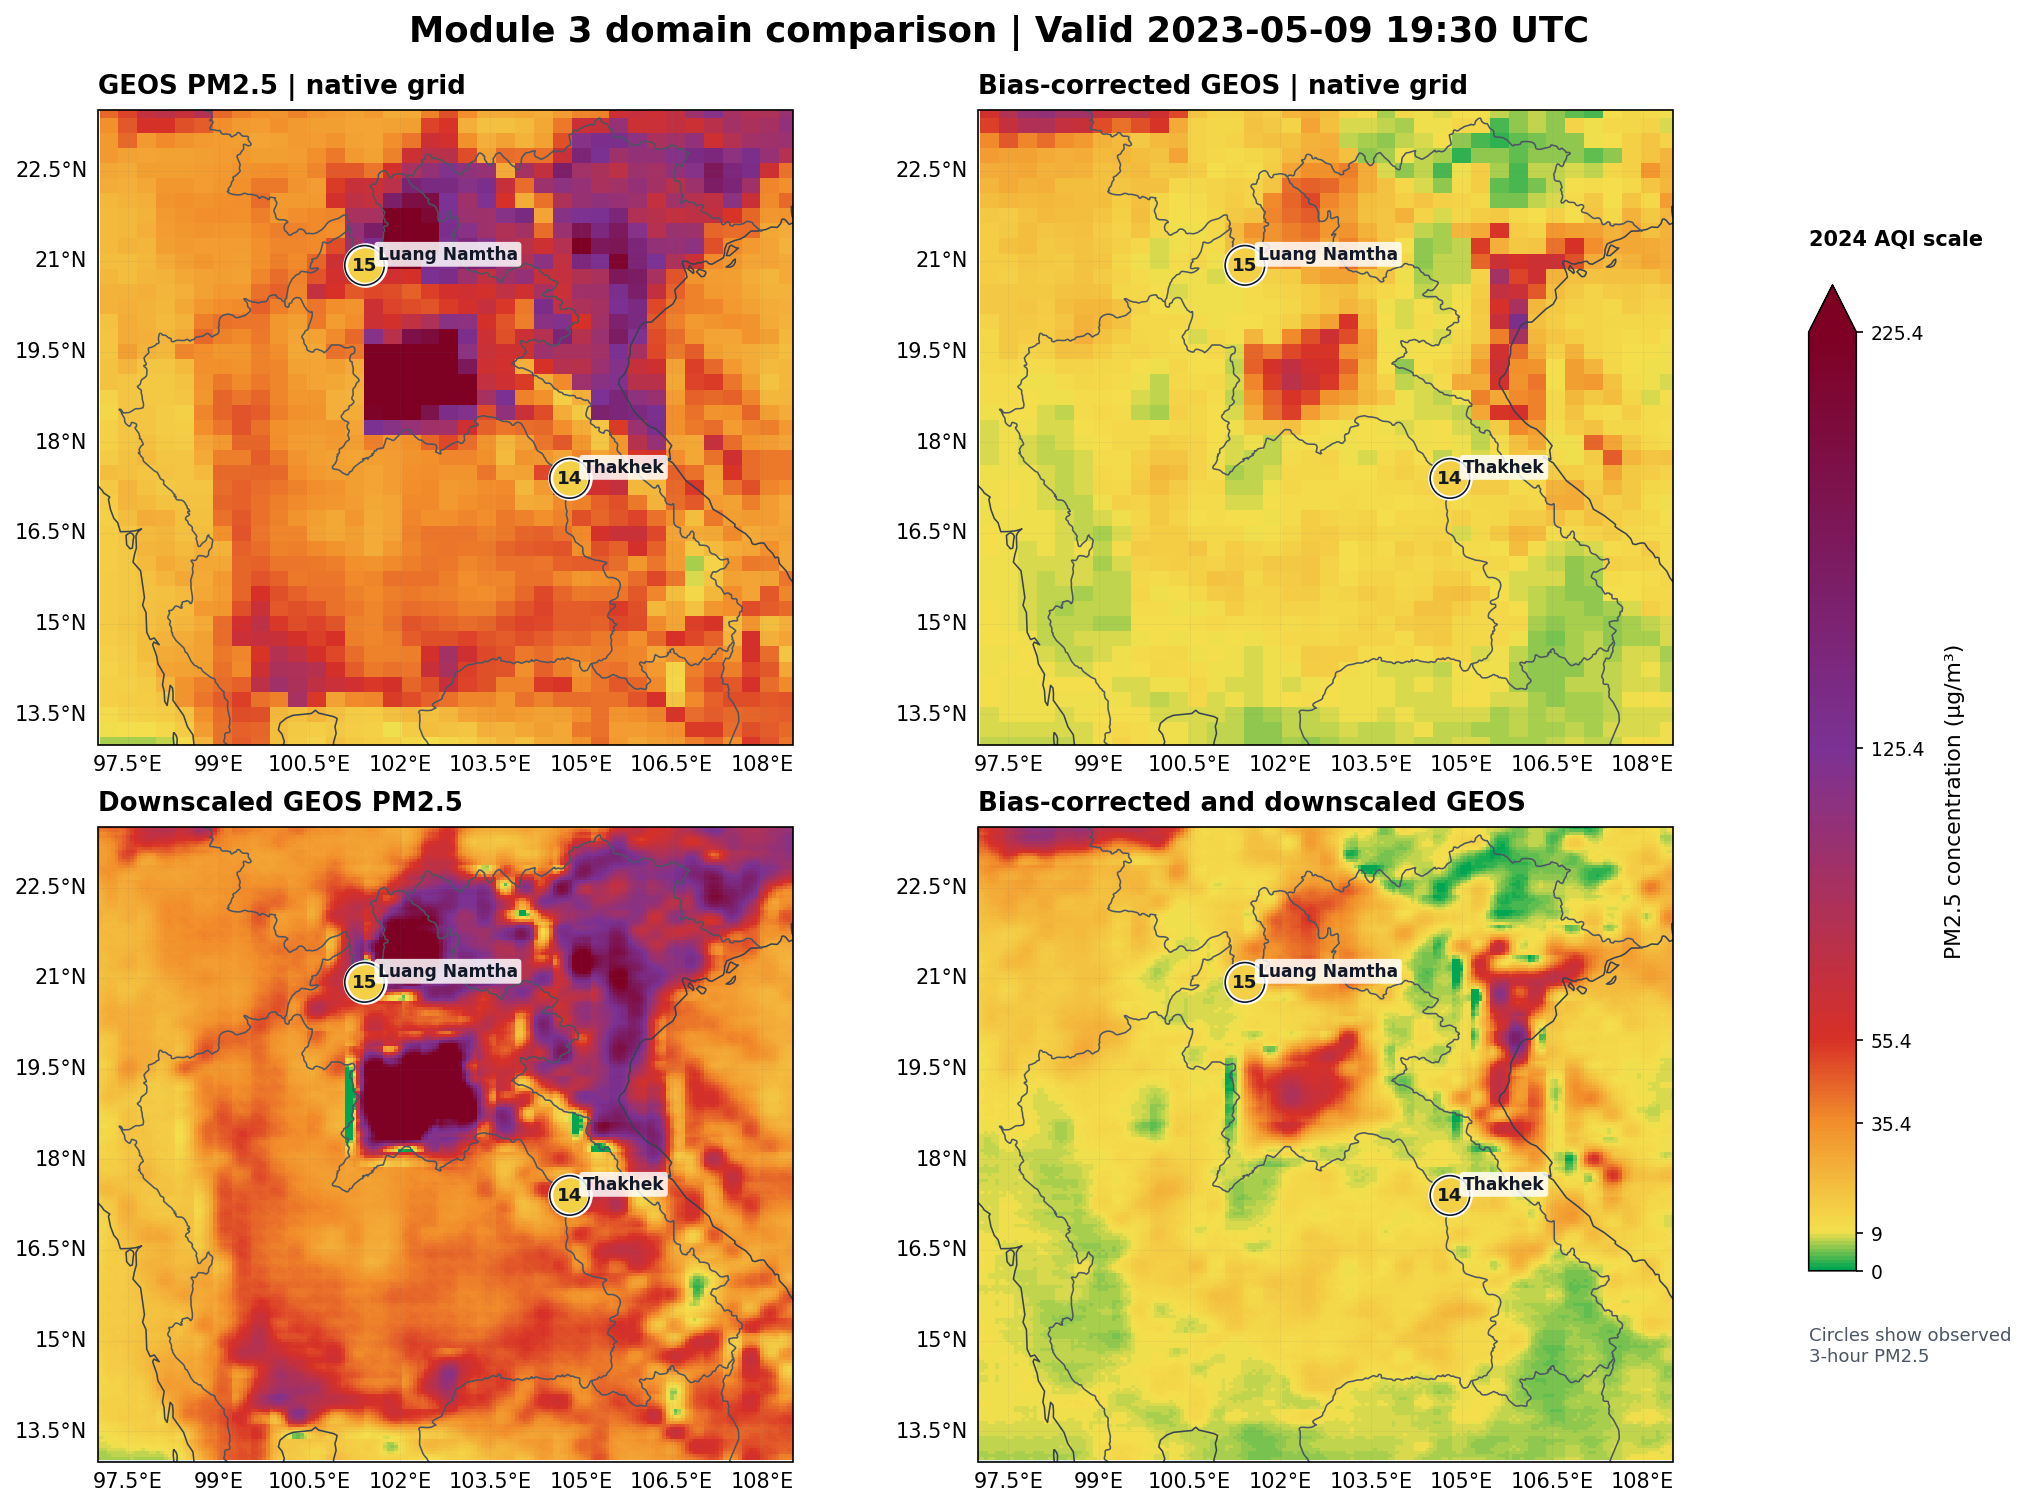

Saved: {TRAINING_ROOT}/outputs/module3/module3_four_panel_domain_comparison_20230509_1930.png


In [13]:
# --- What this cell does ---
# Crops native and downscaled fields to the Lao PDR display domain.
# Uses the 2024 EPA PM2.5 AQI breakpoints to build one continuous shared color scale.
# Places the colorbar outside the maps and prints observed PM2.5 inside station circles.
# Saves the final Module 3 comparison figure.
# --- End annotation ---

DISPLAY_LON = (97.0, 108.5)
DISPLAY_LAT = (13.0, 23.5)
plot_time = native_fields.time.values[0]

native_plot = native_fields.sel(
    lon=slice(*DISPLAY_LON),
    lat=slice(*DISPLAY_LAT),
).sel(time=plot_time)
downscaled_plot = downscaled_fields.sel(
    lon=slice(*DISPLAY_LON),
    lat=slice(*DISPLAY_LAT),
).sel(time=plot_time)

# EPA 2024 PM2.5 concentration breakpoints (24-hour AQI reporting scale).
# The map remains continuous so neighboring concentrations transition smoothly.
AQI_MAX = 225.4
# Use AQI breakpoints as color anchors while retaining a continuous concentration scale.
aqi_breakpoints = np.array([0.0, 9.0, 35.4, 55.4, 125.4, 225.4])
aqi_colors = [
    "#00A651",  # Good
    "#F4E04D",  # Moderate
    "#F28E2B",  # Unhealthy for sensitive groups
    "#D73027",  # Unhealthy
    "#7B3294",  # Very unhealthy
    "#7E0023",  # Hazardous
]
continuous_aqi = LinearSegmentedColormap.from_list(
    "continuous_aqi_2024",
    list(zip(aqi_breakpoints / AQI_MAX, aqi_colors)),
)
# Apply one normalization to every panel so identical colors mean identical PM2.5 values.
color_norm = Normalize(vmin=0, vmax=AQI_MAX, clip=True)

panels = [
    (native_plot["GEOSPM25"], "GEOS PM2.5 | native grid"),
    (native_plot["BC_DNN_PM25"], "Bias-corrected GEOS | native grid"),
    (downscaled_plot["DS_GEOSPM25"], "Downscaled GEOS PM2.5"),
    (downscaled_plot["DS_BC_DNN_PM25"], "Bias-corrected and downscaled GEOS"),
]

projection = ccrs.PlateCarree()
fig, axes = plt.subplots(
    2,
    2,
    figsize=(14.4, 10.6),
    dpi=150,
    subplot_kw={"projection": projection},
)

last_mesh = None
for ax, (field, title) in zip(axes.ravel(), panels):
    last_mesh = ax.pcolormesh(
        field.lon,
        field.lat,
        field,
        cmap=continuous_aqi,
        norm=color_norm,
        shading="auto",
        transform=projection,
        zorder=1,
    )

    # Draw each observation as a readable value badge at its true station coordinate.
    for station in ground_at_valid_time.itertuples(index=False):
        station_value = float(station.ground_pm25_3h)
        badge_color = continuous_aqi(color_norm(station_value))
        text_color = "white" if station_value >= 55.5 else "#111827"
        ax.scatter(
            station.lon,
            station.lat,
            s=360,
            c=[badge_color],
            edgecolors="white",
            linewidths=2.4,
            transform=projection,
            zorder=6,
        )
        ax.scatter(
            station.lon,
            station.lat,
            s=360,
            facecolors="none",
            edgecolors="#111827",
            linewidths=0.8,
            transform=projection,
            zorder=7,
        )
        ax.text(
            station.lon,
            station.lat,
            f"{station_value:.0f}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=8.8,
            fontweight="bold",
            transform=projection,
            zorder=8,
        )
        ax.text(
            station.lon + 0.22,
            station.lat + 0.10,
            station.station_name,
            fontsize=8.2,
            fontweight="semibold",
            color="#111827",
            transform=projection,
            zorder=8,
            bbox={
                "boxstyle": "round,pad=0.2",
                "facecolor": "white",
                "edgecolor": "none",
                "alpha": 0.84,
            },
        )

    ax.set_extent([*DISPLAY_LON, *DISPLAY_LAT], crs=projection)
    ax.add_feature(cfeature.LAND, facecolor="#F4F5F2", zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor="#DCECF2", zorder=0)
    ax.coastlines(resolution="50m", linewidth=0.75, color="#374151")
    ax.add_feature(cfeature.BORDERS, linewidth=0.75, edgecolor="#4B5563")
    gridlines = ax.gridlines(
        draw_labels=True,
        linewidth=0.3,
        color="#6B7280",
        alpha=0.32,
        linestyle=":",
    )
    gridlines.top_labels = False
    gridlines.right_labels = False
    ax.set_title(title, loc="left", fontsize=12.5, fontweight="semibold", pad=8)

# Reserve a dedicated strip so the colorbar never overlaps or shrinks a map panel.
fig.subplots_adjust(top=0.91, bottom=0.06, left=0.055, right=0.84, hspace=0.13, wspace=0.08)
colorbar_axis = fig.add_axes([0.875, 0.18, 0.022, 0.62])
colorbar = fig.colorbar(last_mesh, cax=colorbar_axis, orientation="vertical", extend="max")
colorbar.set_label("PM2.5 concentration (µg/m³)", fontsize=10.5, labelpad=10)
colorbar.set_ticks(aqi_breakpoints)
colorbar.set_ticklabels(["0", "9", "35.4", "55.4", "125.4", "225.4"])
colorbar.ax.tick_params(labelsize=9)

fig.text(
    0.875,
    0.825,
    "2024 AQI scale",
    fontsize=10,
    fontweight="semibold",
    ha="left",
)
fig.text(
    0.875,
    0.145,
    "Circles show observed\n3-hour PM2.5",
    fontsize=8.7,
    color="#4B5563",
    ha="left",
    va="top",
)
fig.suptitle(
    "Module 3 domain comparison | Valid 2023-05-09 19:30 UTC",
    fontsize=17,
    fontweight="semibold",
    y=0.97,
)

four_panel_figure = OUTPUT_DIR / "module3_four_panel_domain_comparison_20230509_1930.png"
fig.savefig(four_panel_figure, dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved:", four_panel_figure)


# Module 3 checkpoint

Participants should now be able to explain:

- why raw GEOS remains the baseline;
- what added complexity linear, RF, and DNN models provide;
- why static global normalization must be reused unchanged;
- why bias correction and spatial downscaling are different operations;
- how v3.1 fold predictions feed the ensemble;
- how all four domain products are compared at matching station coordinates and UTC valid time.

## Short participant exercise

1. Identify the best demonstration model using both RMSE and IOA. Do the two metrics agree?
2. Select one feature whose normalized values exceed `[0, 1]`. Explain what that means operationally.
3. Compare the sign of `v3.1 corrected - GEOS` at Thakhek and Luang Namtha.
4. Explain why the two-station map overlay is a workflow demonstration rather than a validation result.
